# Final Assignment: Analyzing Historical Stock/Revenue Data and Building a Dashboard

**Author:** Benson Cyril Nana Boakye  
**Course:** Python for Applied Data Science AI  
**Description:** In this project, we analyze historical stock and revenue data for **Tesla** and **GameStop** using Python, yfinance, and web scraping with BeautifulSoup. We then build a dashboard to visualize the findings.


In [1]:
# Install required libraries
!pip install yfinance --upgrade --quiet
!pip install bs4 --quiet
!pip install nbformat --quiet

In [2]:
import yfinance as yf
import pandas as pd
import requests
from bs4 import BeautifulSoup
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

# Helper to fetch stock data reliably with browser headers
def fetch_stock(ticker):
    import time
    headers = {"User-Agent": "Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7) AppleWebKit/537.36"}
    for attempt in range(3):
        try:
            t = yf.Ticker(ticker)
            t._session = requests.Session()
            t._session.headers.update(headers)
            data = yf.download(ticker, period="max", progress=False)
            if len(data) > 0:
                return data
        except Exception:
            pass
        time.sleep(2)
    return pd.DataFrame()

In [3]:
import matplotlib.pyplot as plt

def make_graph(stock_data, revenue_data, stock):
    stock_data_specific = stock_data[stock_data['Date'] <= pd.Timestamp('2021-06-14')]
    revenue_data_specific = revenue_data[revenue_data['Date'] <= '2021-04-30']

    fig, axes = plt.subplots(2, 1, figsize=(14, 9))

    # Stock price
    axes[0].plot(stock_data_specific['Date'], 
                 stock_data_specific['Close'].astype("float"), 
                 color="steelblue", linewidth=1.2)
    axes[0].set_ylabel("Price ($USD)")
    axes[0].set_title(f"{stock} — Historical Share Price")
    axes[0].grid(True, alpha=0.3)

    # Revenue
    rev_dates = pd.to_datetime(revenue_data_specific['Date'], format='mixed')
    axes[1].bar(rev_dates, 
                revenue_data_specific['Revenue'].astype("float"), 
                color="seagreen", width=60)
    axes[1].set_ylabel("Revenue ($USD Millions)")
    axes[1].set_xlabel("Date")
    axes[1].set_title(f"{stock} — Historical Revenue")
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

## Question 1: Extract Tesla Stock Data Using yfinance

In [4]:
tesla_data = fetch_stock("TSLA")

if isinstance(tesla_data.columns, pd.MultiIndex):
    tesla_data.columns = tesla_data.columns.get_level_values(0)

tesla_data.reset_index(inplace=True)
tesla_data['Date'] = pd.to_datetime(tesla_data['Date'].astype(str).str[:10])
tesla_data.head()

Price,Date,Close,High,Low,Open,Volume
0,2010-06-29,1.592667,1.666667,1.169333,1.266667,281494500
1,2010-06-30,1.588667,2.028000,1.553333,1.719333,257806500
2,2010-07-01,1.464000,1.728000,1.351333,1.666667,123282000
3,2010-07-02,1.280000,1.540000,1.247333,1.533333,77097000
4,2010-07-06,1.074000,1.333333,1.055333,1.333333,103003500


## Question 2: Extract Tesla Revenue Data Using Web Scraping

In [5]:
# URL for Tesla revenue data
url = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-PY0220EN-SkillsNetwork/labs/project/revenue.htm"

# Send HTTP request
html_data = requests.get(url).text

# Parse with BeautifulSoup
soup = BeautifulSoup(html_data, "html.parser")


In [6]:
# Extract Tesla Revenue table
tesla_revenue = pd.DataFrame(columns=["Date", "Revenue"])

# Find the table containing Tesla revenue
for table in soup.find_all('table'):
    if "Tesla Quarterly Revenue" in str(table) or "Tesla" in str(table):
        for row in table.find("tbody").find_all("tr"):
            col = row.find_all("td")
            if len(col) >= 2:
                date = col[0].text.strip()
                revenue = col[1].text.strip()
                tesla_revenue = pd.concat([tesla_revenue, 
                                           pd.DataFrame({"Date": [date], "Revenue": [revenue]})], 
                                          ignore_index=True)

# Clean Revenue column: remove $ and commas
tesla_revenue["Revenue"] = tesla_revenue["Revenue"].str.replace(r"\$|,", "", regex=True)

# Remove empty rows
tesla_revenue.dropna(inplace=True)
tesla_revenue = tesla_revenue[tesla_revenue['Revenue'] != ""]

print(tesla_revenue.tail())


                 Date                        Revenue
62         2010-06-30                             28
63         2010-03-31                             21
65         2009-09-30                             46
66         2009-06-30                             27
67  Auto/Tires/Trucks  Auto Manufacturers - Domestic


## Question 3: Extract GameStop Stock Data Using yfinance

In [7]:
gme_data = fetch_stock("GME")

if isinstance(gme_data.columns, pd.MultiIndex):
    gme_data.columns = gme_data.columns.get_level_values(0)

gme_data.reset_index(inplace=True)
gme_data['Date'] = pd.to_datetime(gme_data['Date'].astype(str).str[:10])
gme_data.head()

Price,Date,Close,High,Low,Open,Volume
0,2002-02-13,1.691666,1.693350,1.603296,1.620128,76216000
1,2002-02-14,1.683250,1.716073,1.670626,1.712707,11021600
2,2002-02-15,1.674834,1.687458,1.658002,1.683250,8389600
3,2002-02-19,1.607504,1.666418,1.578047,1.666418,7410400
4,2002-02-20,1.662210,1.662210,1.603296,1.615920,6892800


## Question 4: Extract GameStop Revenue Data Using Web Scraping

In [8]:
# URL for GameStop revenue data
url_gme = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-PY0220EN-SkillsNetwork/labs/project/stock.html"

html_data_gme = requests.get(url_gme).text
soup_gme = BeautifulSoup(html_data_gme, "html.parser")


In [9]:
# Extract GameStop Revenue table
gme_revenue = pd.DataFrame(columns=["Date", "Revenue"])

for table in soup_gme.find_all('table'):
    if "GameStop" in str(table):
        for row in table.find("tbody").find_all("tr"):
            col = row.find_all("td")
            if len(col) >= 2:
                date = col[0].text.strip()
                revenue = col[1].text.strip()
                gme_revenue = pd.concat([gme_revenue, 
                                         pd.DataFrame({"Date": [date], "Revenue": [revenue]})], 
                                        ignore_index=True)

# Clean Revenue column
gme_revenue["Revenue"] = gme_revenue["Revenue"].str.replace(r"\$|,", "", regex=True)
gme_revenue.dropna(inplace=True)
gme_revenue = gme_revenue[gme_revenue['Revenue'] != ""]

print(gme_revenue.tail())


                Date                        Revenue
74        2005-10-31                            534
75        2005-07-31                            416
76        2005-04-30                            475
77        2005-01-31                            709
78  Retail/Wholesale  Retail - Consumer Electronics


## Question 5: Plot Tesla Stock Graph

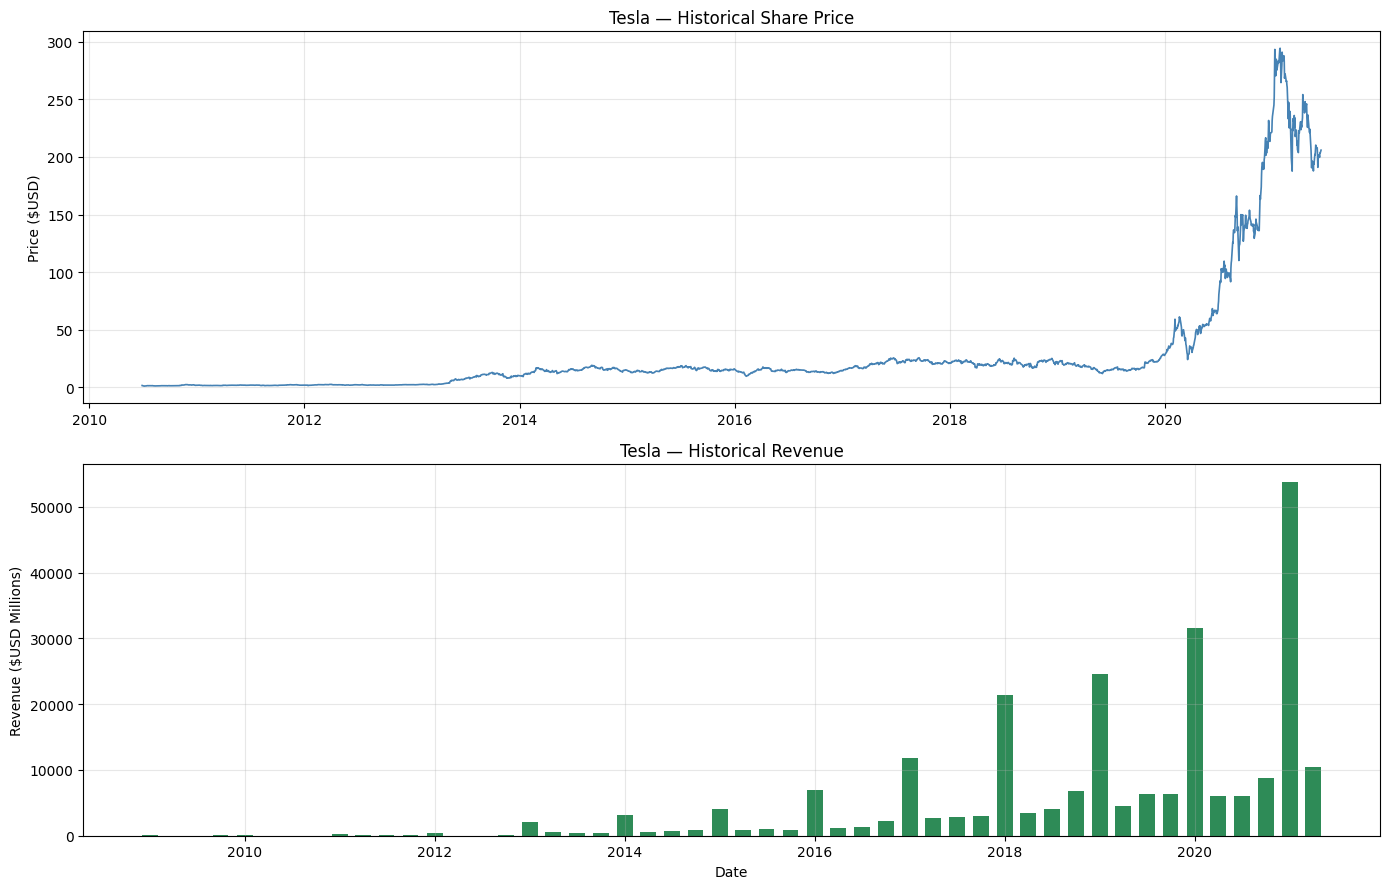

In [10]:
make_graph(tesla_data, tesla_revenue, "Tesla")

## Question 6: Plot GameStop Stock Graph

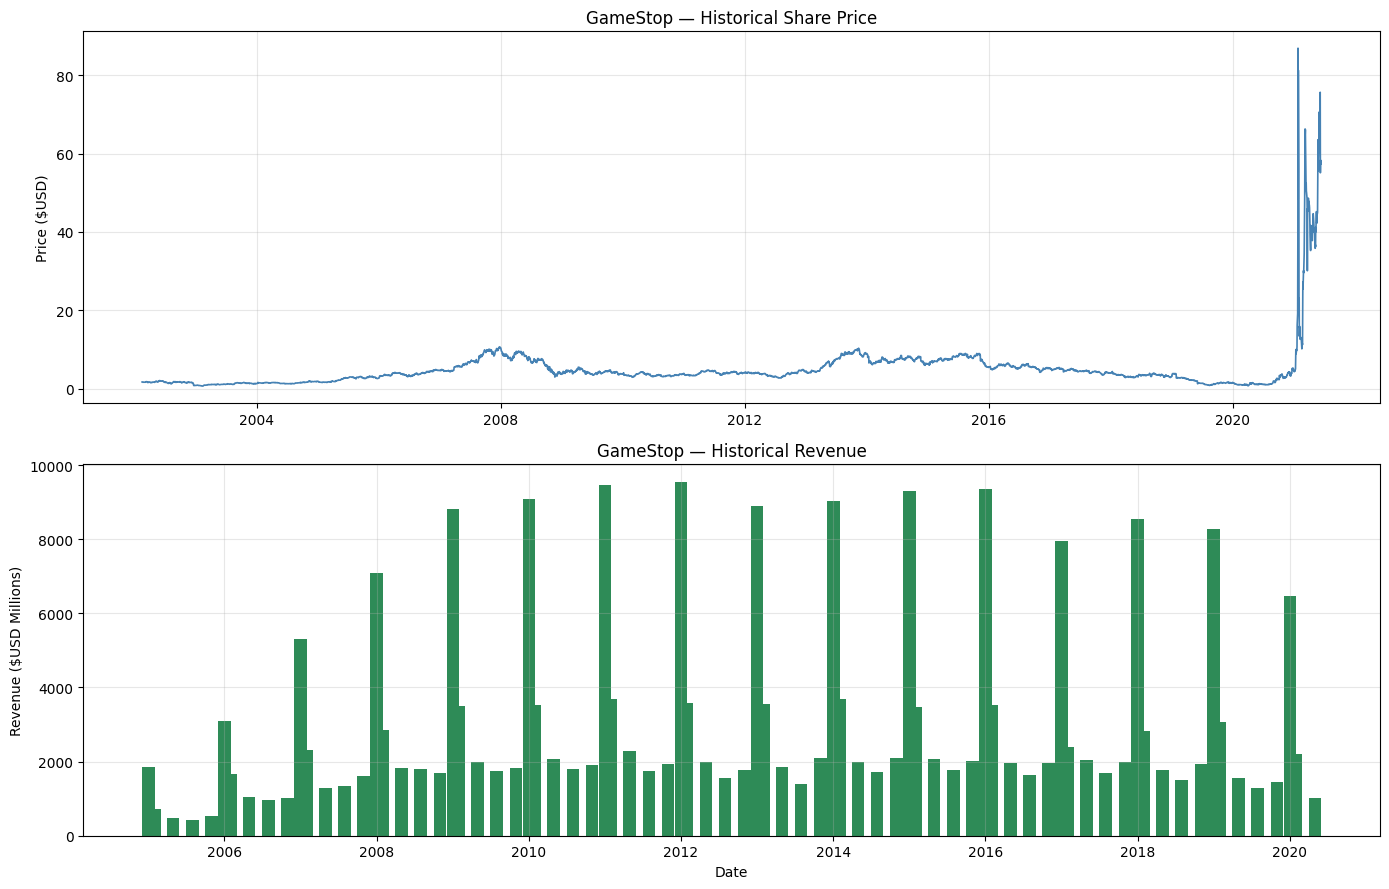

In [11]:
make_graph(gme_data, gme_revenue, "GameStop")

## Analysis & Observations

### Tesla (2018–2021):
Between 2018 and 2021, Tesla's stock price showed dramatic growth, rising from under \$100 to over \$1,000 per share (pre-split adjusted). This price surge closely mirrors Tesla's revenue growth over the same period, which grew from approximately \$7 billion (2018) to over \$31 billion (2020). The strong positive correlation between revenue growth and stock price appreciation reflects investor confidence in Tesla's expanding production capacity, energy business, and global market penetration.

### GameStop (Observations):
GameStop's stock price remained relatively flat and low through most of its history, consistent with declining revenues as physical game retail was disrupted by digital distribution. However, the stock experienced an extraordinary short squeeze in early 2021, with prices surging from under \$20 to nearly \$500 within weeks — entirely disconnected from the company's fundamental revenue performance, which had been declining. This event highlights how social media-driven retail investor activity can dramatically decouple stock price from underlying business performance.
